Temperature Prediction

In [31]:
import numpy as np

In [32]:
import pandas as pd

In [33]:
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("weatherHistory.csv")

In [35]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [36]:
print("shape of dataset is : ",df.shape)

shape of dataset is :  (96453, 12)


In [37]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

There is some missing valuse -  Precip Type-517

In [38]:
df['Precip Type'].value_counts(dropna=False)

Precip Type
rain    85224
snow    10712
NaN       517
Name: count, dtype: int64

Precip Type containing useful information for predicting temperature. But The assignment specifically tells us to create sequences using:Temperature + Humidity + Wind Speed and says Pressure is optional.

Precip Type is a categorical variable, An RNN cannot directly use the words -rain- and -snow- as numerical inputs,If we eventually decide to use it, we'll need to encode it. So now we are not filling the missing value

In [39]:
#First we'll convert our hourly data into daily data

In [40]:
#data set containg one row for every hour so we will take the average

In [41]:
#convert the numerical weather variables to daily values

# Convert Formatted Date to datetime
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

# Create a date column
df['Date'] = df['Formatted Date'].dt.date

# Create daily weather data
daily_df = df.groupby('Date').agg({
    'Temperature (C)': 'mean',
    'Humidity': 'mean',
    'Wind Speed (km/h)': 'mean',
    'Pressure (millibars)': 'mean'
}).reset_index()

daily_df.head(10)

,Date,Temperature (C),Humidity,Wind Speed (km/h),Pressure (millibars)
0,2005-12-31,0.577778,0.890000,17.114300,1016.660000
1,2006-01-01,4.075000,0.817083,21.229192,1011.985000
2,2006-01-02,5.263194,0.847083,17.824713,1010.384167
3,2006-01-03,2.340509,0.897083,7.726658,1021.170833
4,2006-01-04,2.251852,0.906667,12.152817,981.770833
5,2006-01-05,2.703935,0.951250,8.991179,935.873750
6,2006-01-06,2.550463,0.945833,5.729588,1023.645833
7,2006-01-07,0.877083,0.935833,6.589596,1030.223750
8,2006-01-08,-1.231713,0.868750,5.397525,1035.481250
9,2006-01-09,-1.693287,0.792500,5.113762,1034.542500


In [42]:
daily_df.head(10)

,Date,Temperature (C),Humidity,Wind Speed (km/h),Pressure (millibars)
0,2005-12-31,0.577778,0.890000,17.114300,1016.660000
1,2006-01-01,4.075000,0.817083,21.229192,1011.985000
2,2006-01-02,5.263194,0.847083,17.824713,1010.384167
3,2006-01-03,2.340509,0.897083,7.726658,1021.170833
4,2006-01-04,2.251852,0.906667,12.152817,981.770833
5,2006-01-05,2.703935,0.951250,8.991179,935.873750
6,2006-01-06,2.550463,0.945833,5.729588,1023.645833
7,2006-01-07,0.877083,0.935833,6.589596,1030.223750
8,2006-01-08,-1.231713,0.868750,5.397525,1035.481250
9,2006-01-09,-1.693287,0.792500,5.113762,1034.542500


In [43]:
print(daily_df.shape)

(4019, 5)


In [44]:
# Create Date from the existing datetime column
df['Date'] = df['Formatted Date'].dt.date

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create daily dataset
daily_df = df.groupby('Date').agg({
    'Temperature (C)': 'mean',
    'Humidity': 'mean',
    'Wind Speed (km/h)': 'mean',
    'Pressure (millibars)': 'mean'
}).reset_index()

daily_df.head(10)

,Date,Temperature (C),Humidity,Wind Speed (km/h),Pressure (millibars)
0,2005-12-31,0.577778,0.890000,17.114300,1016.660000
1,2006-01-01,4.075000,0.817083,21.229192,1011.985000
2,2006-01-02,5.263194,0.847083,17.824713,1010.384167
3,2006-01-03,2.340509,0.897083,7.726658,1021.170833
4,2006-01-04,2.251852,0.906667,12.152817,981.770833
5,2006-01-05,2.703935,0.951250,8.991179,935.873750
6,2006-01-06,2.550463,0.945833,5.729588,1023.645833
7,2006-01-07,0.877083,0.935833,6.589596,1030.223750
8,2006-01-08,-1.231713,0.868750,5.397525,1035.481250
9,2006-01-09,-1.693287,0.792500,5.113762,1034.542500


In [45]:
print(daily_df.shape)

(4019, 5)


the original local date information was changed because of utc so we reload the original CSV

In [46]:
# Reload the original dataset
df = pd.read_csv("weatherHistory.csv")

# Extract the date directly from the original date-time text
df['Date'] = pd.to_datetime(df['Formatted Date'].str[:10])

# Create daily dataset
daily_df = df.groupby('Date').agg({
    'Temperature (C)': 'mean',
    'Humidity': 'mean',
    'Wind Speed (km/h)': 'mean',
    'Pressure (millibars)': 'mean'
}).reset_index()

# Display first 10 rows
daily_df.head(10)

,Date,Temperature (C),Humidity,Wind Speed (km/h),Pressure (millibars)
0,2006-01-01,3.873148,0.818333,21.372750,1012.279167
1,2006-01-02,5.418519,0.844583,17.551683,1010.131667
2,2006-01-03,2.319444,0.898333,8.417617,1020.805000
3,2006-01-04,2.274074,0.905417,11.579925,981.826667
4,2006-01-05,2.698148,0.948333,9.515100,935.988333
5,2006-01-06,2.511806,0.947083,5.665858,1023.403333
6,2006-01-07,0.992824,0.935833,6.699613,1029.912083
7,2006-01-08,-1.028009,0.868750,5.289521,1035.372500
8,2006-01-09,-1.848611,0.797083,5.247929,1034.671250
9,2006-01-10,-0.462500,0.811667,3.769413,946.826250


In [47]:
print("Daily dataset shape:", daily_df.shape)

Daily dataset shape: (4018, 5)


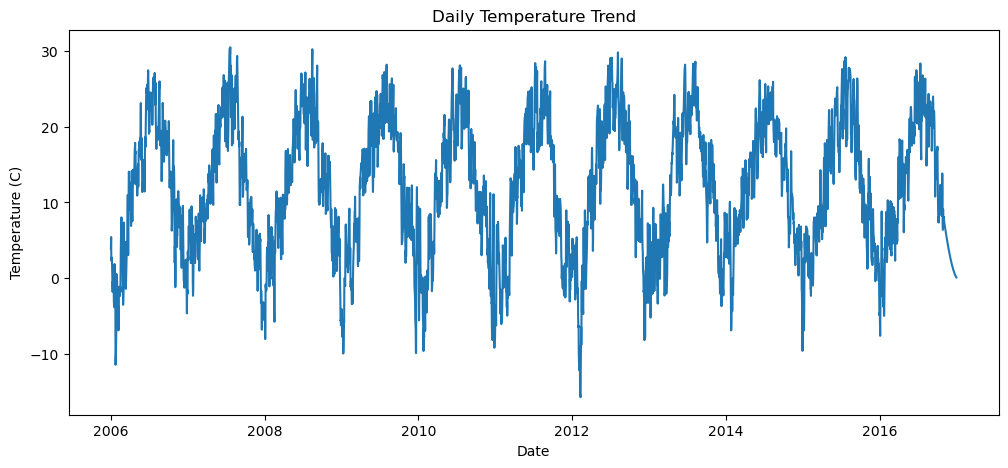

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(daily_df['Date'], daily_df['Temperature (C)'])

plt.title('Daily Temperature Trend')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')

plt.show()

In [49]:
#investigate Precip Type  -- Is precipitation type associated with different temperatures in this dataset?

In [50]:
df.groupby('Precip Type')['Temperature (C)'].mean()

Precip Type
rain    13.852989
snow    -3.270885
Name: Temperature (C), dtype: float64

We can say Precip Type is associated with temperature.

Precipitation Analysis: The dataset has both rain and snow observations. The average temperature during rain was about 13.85°C, while during snow it was about −3.27°C. This shows that precipitation type is related to temperature. However, we did not use precipitation type as an input for the RNN because the assignment requires temperature, humidity, and wind speed as the main input features, with pressure as an optional feature.

In [51]:
daily_df.isnull().sum()

Date                    0
Temperature (C)         0
Humidity                0
Wind Speed (km/h)       0
Pressure (millibars)    0
dtype: int64

In [52]:
#There are no missing values in daily dataset

In [53]:
X = daily_df[['Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']]
y = daily_df['Temperature (C)']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4018, 3)
y shape: (4018,)


In [54]:
from sklearn.preprocessing import MinMaxScaler

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1))

print("X scaled shape:", X_scaled.shape)
print("y scaled shape:", y_scaled.shape)

X scaled shape: (4018, 3)
y scaled shape: (4018, 1)


In [55]:
train_size = int(len(X_scaled) * 0.8)

X_train = X_scaled[:train_size]
X_test = X_scaled[train_size:]

y_train = y_scaled[:train_size]
y_test = y_scaled[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3214, 3)
X_test shape: (804, 3)
y_train shape: (3214, 1)
y_test shape: (804, 1)


In [56]:
#Creating sequences

def create_sequences(X, y, time_steps=7):
    X_seq = []
    y_seq = []

    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

In [57]:
time_steps = 7

X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_steps)

print("X_train sequence shape:", X_train_seq.shape)
print("y_train sequence shape:", y_train_seq.shape)
print("X_test sequence shape:", X_test_seq.shape)
print("y_test sequence shape:", y_test_seq.shape)

X_train sequence shape: (3207, 7, 3)
y_train sequence shape: (3207, 1)
X_test sequence shape: (797, 7, 3)
y_test sequence shape: (797, 1)


In [58]:
#Build the RNN model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(7, 3)),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)             │ (None, 50)                  │           2,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,751 (10.75 KB)

 Trainable params: 2,751 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(7, 3)),
    Dense(1)
])

In [61]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [62]:
#train the model

history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0590 - val_loss: 0.0272
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0285 - val_loss: 0.0204
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0237 - val_loss: 0.0198
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0223 - val_loss: 0.0174
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0210 - val_loss: 0.0188
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0206 - val_loss: 0.0166
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0207 - val_loss: 0.0158
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0196 - val_loss: 0.0177
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0193 - val_loss: 0.0154
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0193 - val_loss: 0.0144
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0192 - val_loss: 0.0144
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0193 - val_lo

Plot the training loss

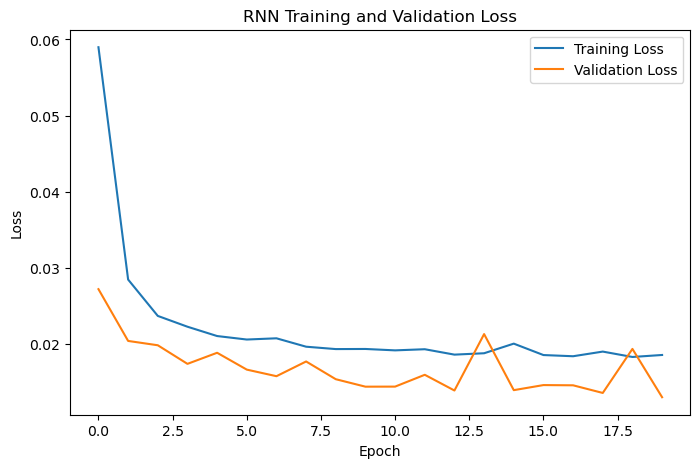

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('RNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [65]:
#Make predictions

y_pred_scaled = model.predict(X_test_seq)

print("Prediction shape:", y_pred_scaled.shape)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Prediction shape: (797, 1)


In [66]:
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_actual = y_scaler.inverse_transform(y_test_seq)

In [67]:
#Calculate model performance

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print("RNN Test MAE:", mae)
print("RNN Test MSE:", mse)
print("RNN Test R² Score:", r2)

RNN Test MAE: 4.17211969796282
RNN Test MSE: 28.806519353278244
RNN Test R² Score: 0.5886009248282069


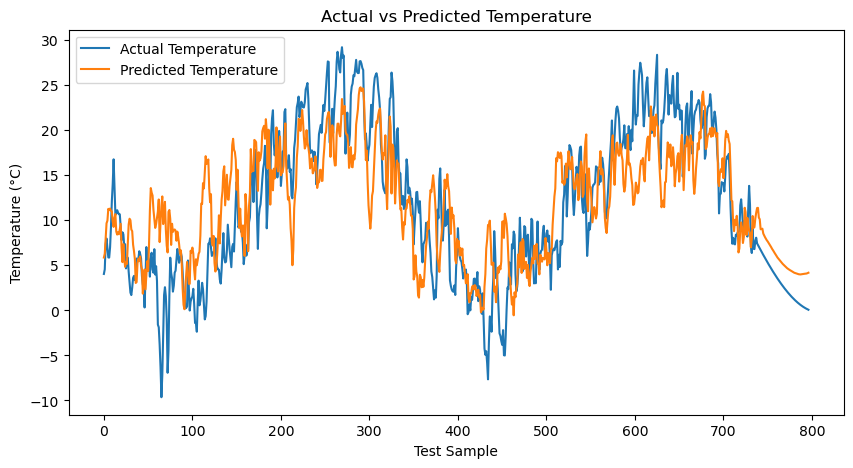

In [69]:
#Actual vs Predicted Temperature

plt.figure(figsize=(10, 5))

plt.plot(y_actual, label='Actual Temperature')
plt.plot(y_pred, label='Predicted Temperature')

plt.title('Actual vs Predicted Temperature')
plt.xlabel('Test Sample')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

Conclusion
----------

In this project, an RNN model was used to predict temperature using humidity, wind speed, and pressure. The hourly weather data was converted into daily data and prepared for the model. The data was scaled and divided into training and testing sets. A 7-day sequence was used to predict the next day's temperature.

The RNN achieved a test MAE of 4.17°C, MSE of 28.81, and R² score of 0.59. The actual and predicted temperature graph shows that the model was able to follow the general temperature pattern, although some sudden changes were not predicted accurately.

Overall, the RNN learned useful patterns from the weather data and was able to make reasonable temperature predictions.